In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df=pd.read_csv("Sample - Superstore.csv", encoding='cp1252')
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


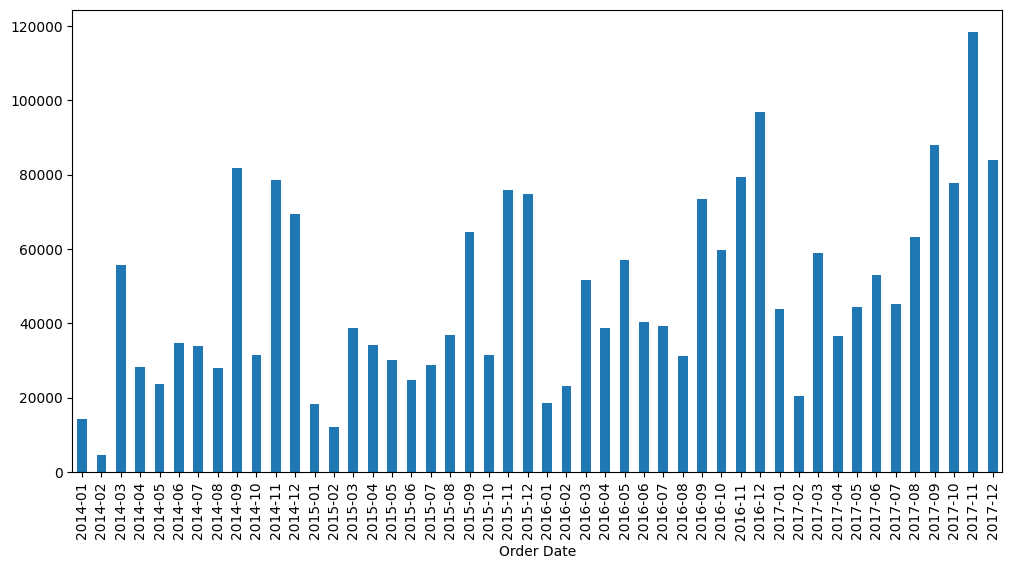

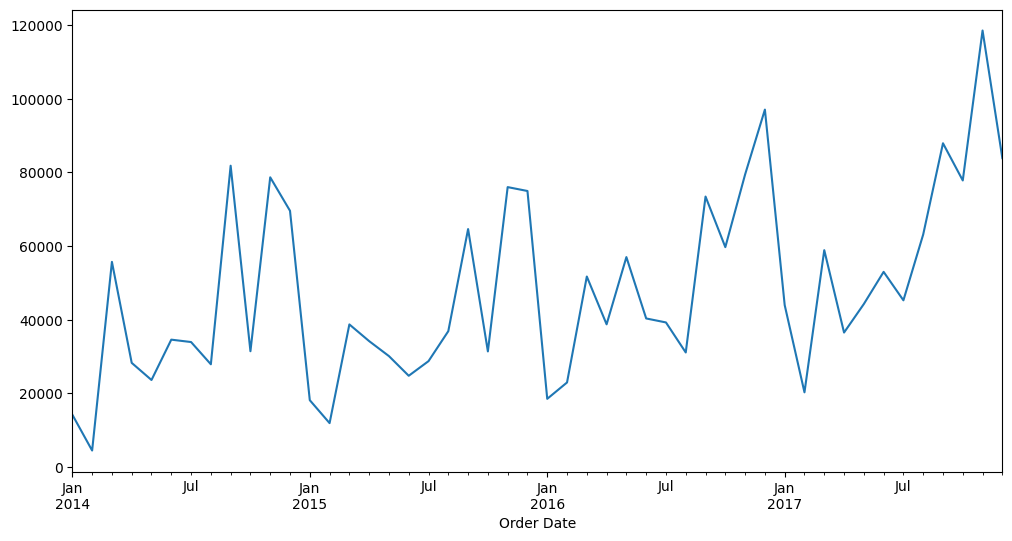

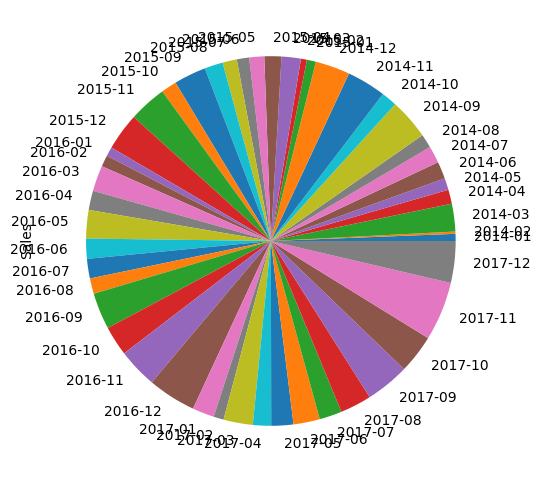

In [16]:
#task1
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales.plot(kind='bar', figsize=(12,6))
plt.show()
monthly_sales.plot(kind='line', figsize=(12,6))
plt.show()
monthly_sales.plot(kind='pie', figsize=(12,6))
plt.show()

#line chart is best because it shows clearly the trends in each year whether
#its increasing or decreasing.


Sub-Category
Phones     330007.054
Chairs     328449.103
Storage    223843.608
Tables     206965.532
Binders    203412.733
Name: Sales, dtype: float64


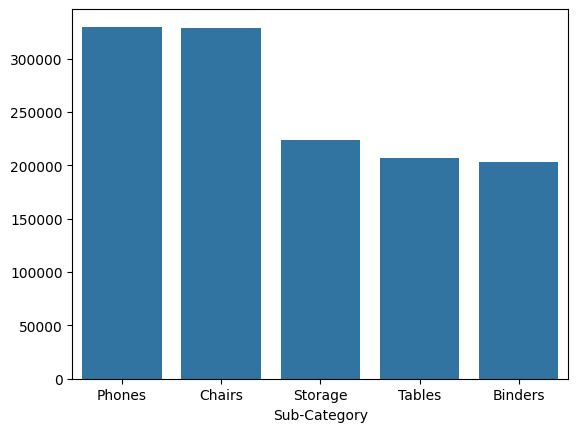

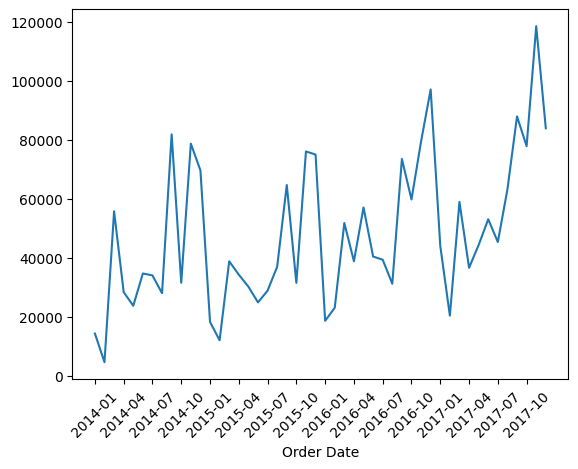

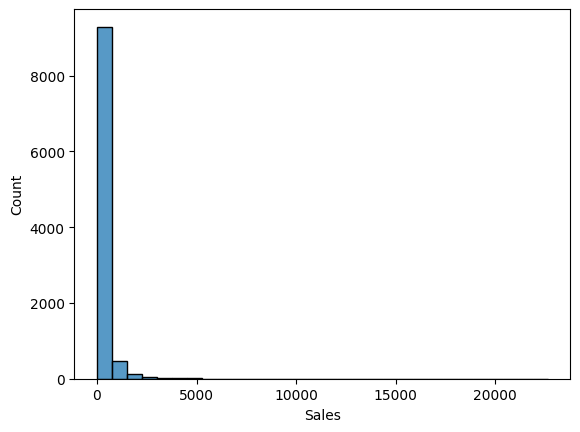

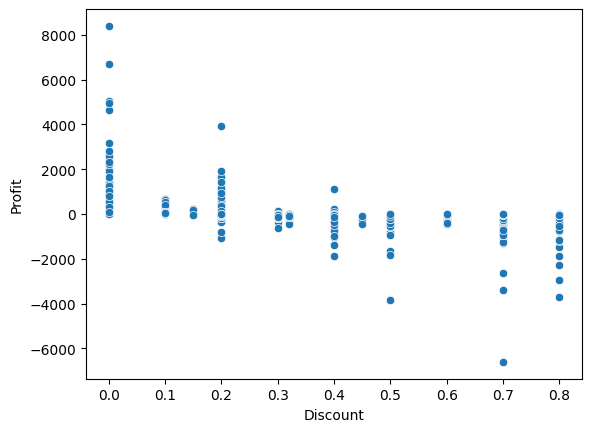

In [50]:
#task2
top_5=df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(5)
print(top_5)
sns.barplot(x=top_5.index, y=top_5.values)
plt.show()
#makes it easy to compare the total sales of the five sub-categories
#a pie chart would be a weaker choice because it is harder to compare similar sized slices accurately

sns.lineplot(x=monthly_sales.index.astype(str), y=monthly_sales.values)
plt.xticks(rotation=45)
plt.xticks(range(0,len(monthly_sales), 3))
plt.show()
#shows how sales increase or decrease over time
#pie chart would be weak  because it shows proportions


sns.histplot(df['Sales'], bins=30)
plt.show()
#shows how the sales values are distributed and how frequently different values occur
#bar would be difficult to cpmapere



sns.scatterplot(x='Discount', y='Profit', data=df)
plt.show()

#shows the relationship between two numerical variables and discount and profit

/tmp/ipykernel_5790/2144019804.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette='Set2')


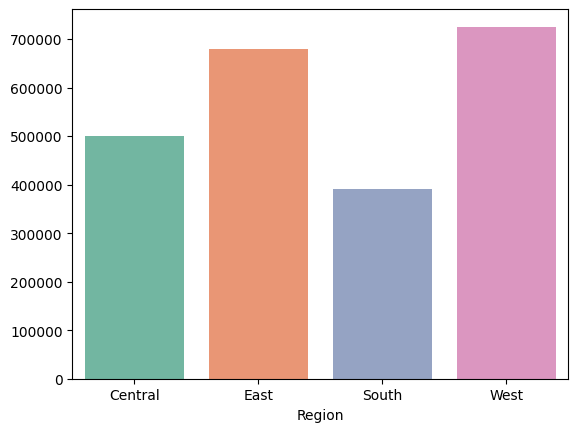

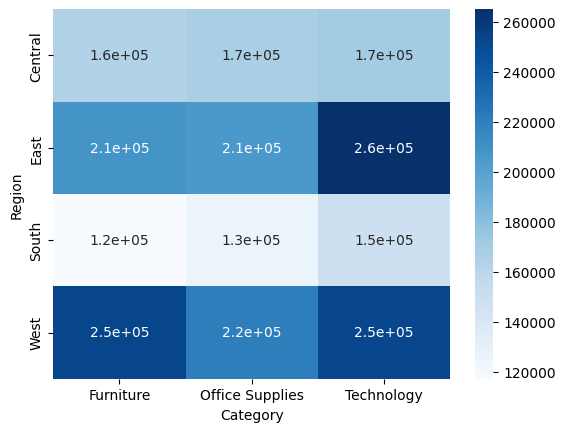

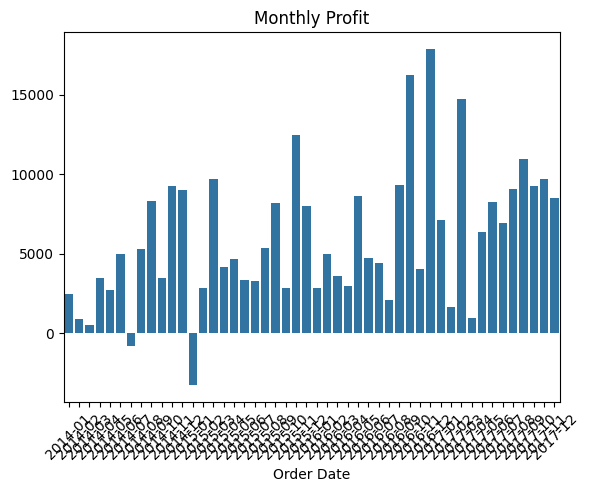

In [66]:
#task3
#(a)
region_sales = df.groupby('Region')['Sales'].sum()
region_category = df.groupby(['Region', 'Category'])['Sales'].sum().unstack()
monthly_profit = df.groupby(df['Order Date'].dt.to_period('M'))['Profit'].sum()

sns.barplot(x=region_sales.index, y=region_sales.values, palette='Set2')
plt.show()

#(b)
sns.heatmap(region_category, annot=True, cmap='Blues')
plt.show()

#(c)
sns.barplot(x=monthly_profit.index.astype(str), y=monthly_profit.values)

plt.xticks(rotation=45)
plt.title('Monthly Profit')
plt.show()

green 2.14 FAIL
orange 2.3 FAIL
purple 2.62 FAIL
pink 2.38 FAIL


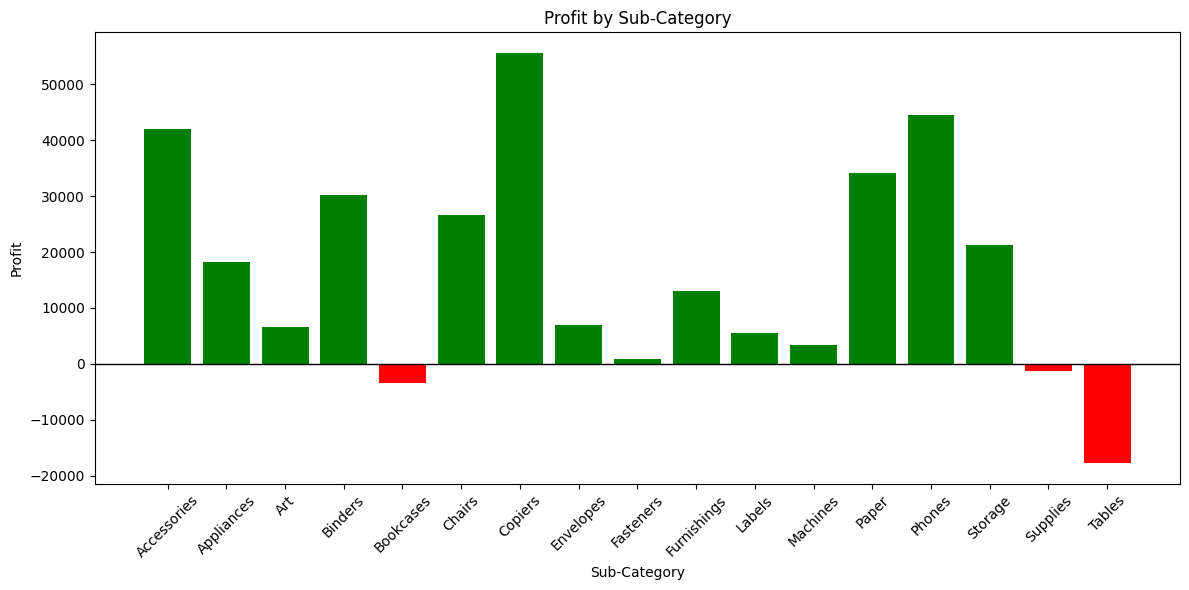

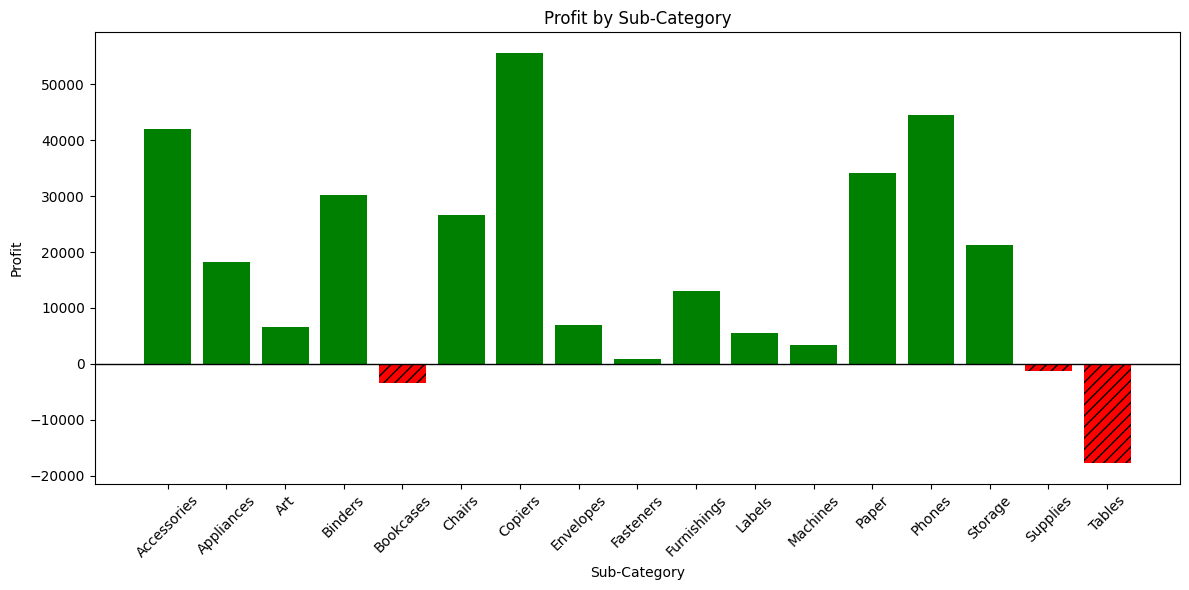

In [64]:
#task4
def contrast_ratio(rgb1, rgb2):

    def relative_luminance(rgb):
        rgb = [c / 255 for c in rgb]

        rgb = [
            c / 12.92 if c <= 0.03928
            else ((c + 0.055) / 1.055) ** 2.4
            for c in rgb
        ]

        return (
            0.2126 * rgb[0] +
            0.7152 * rgb[1] +
            0.0722 * rgb[2]
        )

    l1 = relative_luminance(rgb1)
    l2 = relative_luminance(rgb2)

    lighter = max(l1, l2)
    darker = min(l1, l2)

    return (lighter + 0.05) / (darker + 0.05)


# Colors used in Task 3(a)
colors = {
    'green': (102, 194, 165),
    'orange': (252, 141, 98),
    'purple': (141, 160, 203),
    'pink': (231, 138, 195)
}

# White background
background = (255, 255, 255)

# Check each color against white
for name, color in colors.items():

    ratio = contrast_ratio(color, background)

    if ratio >= 4.5:
        print(name, round(ratio, 2), "PASS")
    else:
        print(name, round(ratio, 2), "FAIL")


# Calculate total profit for each sub-category
profit_data = df.groupby('Sub-Category')['Profit'].sum().reset_index()



colors = [
    'red' if x < 0 else 'green'
    for x in profit_data['Profit']
]

plt.figure(figsize=(12, 6))

plt.bar(
    profit_data['Sub-Category'],
    profit_data['Profit'],
    color=colors
)

plt.axhline(0, color='black', linewidth=1)

plt.xlabel('Sub-Category')
plt.ylabel('Profit')
plt.title('Profit by Sub-Category')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


colors = [
    'red' if x < 0 else 'green'
    for x in profit_data['Profit']
]

hatches = [
    '///' if x < 0 else ''
    for x in profit_data['Profit']
]

plt.figure(figsize=(12, 6))

bars = plt.bar(
    profit_data['Sub-Category'],
    profit_data['Profit'],
    color=colors
)

# Add hatching to loss bars
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

plt.axhline(0, color='black', linewidth=1)

plt.xlabel('Sub-Category')
plt.ylabel('Profit')
plt.title('Profit by Sub-Category')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


# Alt text:
# Bar chart showing profit by sub-category, with green bars representing gains
# and red hatched bars representing losses.

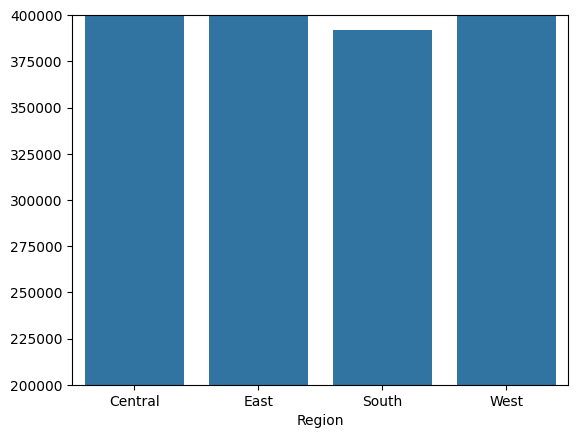

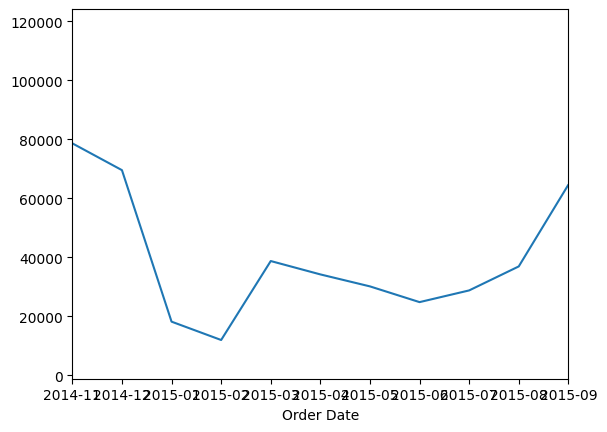

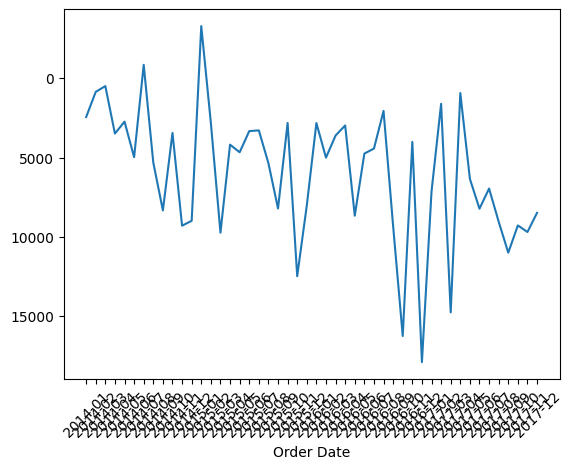

In [65]:
#task5
# 1. Truncated y-axis

sns.barplot(x=region_sales.index, y=region_sales.values)
plt.ylim(200000, 400000)
plt.show()
sns.lineplot(x=monthly_sales.index.astype(str), y=monthly_sales.values)

plt.xlim(10, 20)
plt.show()
# Caption: Cherry-picked date window hides the surrounding trend.


# inverted y-axis

sns.lineplot(x=monthly_profit.index.astype(str), y=monthly_profit.values)
plt.gca().invert_yaxis()
plt.xticks(rotation=45)
plt.show()

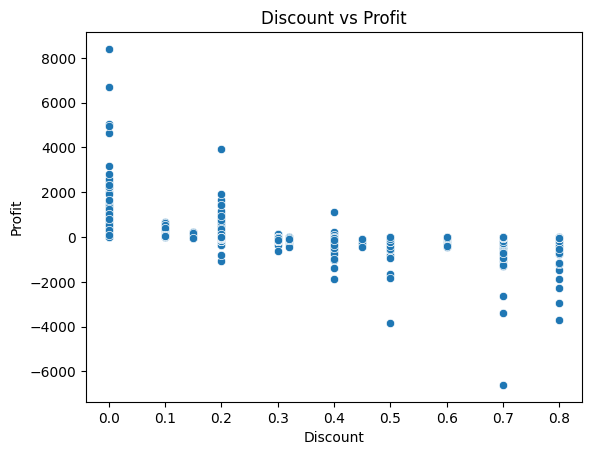

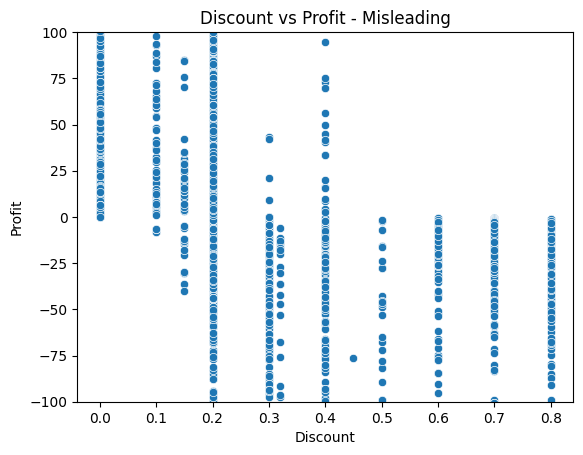

In [69]:
#task6
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title('Discount vs Profit')
plt.show()

sns.scatterplot(x='Discount', y='Profit', data=df)
plt.ylim(-100, 100)
plt.title('Discount vs Profit - Misleading')
plt.show()

#scatter plot is appropriate because it shows the relationship between two numerical variables and discount and profit
#second chart uses a truncated axis, which amplifies the relationship between discount and profit